### **Cuaderno14 MCC225: Tarea individual para la Segunda Exposición Académica Programada**

#### **Evaluación experimental de sistemas multimodales con datos reales**

Este cuaderno es una base de trabajo individual. Cada estudiante debe resolverlo, ejecutarlo con datos reales, guardar los resultados en su repositorio y usar sus hallazgos como soporte para la Segunda Exposición Académica Programada.

El objetivo no es hacer una demostración visual, sino construir una evaluación reproducible de un sistema multimodal. El trabajo conecta BERT, VisualBERT, UNITER, ViLT, BLIP, BLIP-2, LLaVA, CoCa, DALL E 2 y modelos de difusión latente desde una pregunta experimental común: ¿el sistema alinea correctamente imagen y texto, cuándo falla y cómo se documenta ese fallo?-

### **Reglas del trabajo individual**

#### **Condiciones mínimas**

El trabajo es individual. Cada estudiante debe mantener este cuaderno resuelto en su propio repositorio. No se acepta únicamente una exposición oral sin evidencia ejecutable.

El repositorio debe contener como mínimo:

```text
.
├── notebooks/
│   └── Cuaderno14_MSR_VTT.ipynb
├── data/
│   ├── raw/
│   └── processed/
├── outputs/
│   ├── figures/
│   ├── tables/
│   └── metrics/
├── reports/
│   └── reporte_exposicion_2.md
├── requirements.txt
└── README.md
```

El estudiante debe entregar resultados reales, no capturas aisladas. El cuaderno debe producir archivos de métricas, tablas de errores, figuras y un reporte técnico breve.

### **Qué se debe demostrar**

#### Preguntas experimentales

El trabajo debe responder estas preguntas:

1. ¿Qué tan bien alinea el modelo imágenes y textos reales?
2. ¿Qué cambia al degradar la imagen o perturbar los captions?
3. ¿Qué errores aparecen con mayor frecuencia?
4. ¿Qué métrica captura mejor cada tipo de comportamiento?
5. ¿Qué limitaciones quedan fuera de las métricas automáticas?
6. ¿El experimento es reproducible por otra persona?

La exposición debe sostenerse en evidencia del repositorio: métricas, tablas, ejemplos correctos, ejemplos fallidos y discusión de limitaciones.

### **Instalación sugerida**

#### **Dependencias**

Ejecute esta celda solo si el entorno no tiene las bibliotecas requeridas. En un repositorio serio, la misma lista debe aparecer en `requirements.txt`.

In [ ]:
# %pip install -q torch torchvision transformers datasets pillow pandas numpy scikit-learn matplotlib tqdm nltk evaluate accelerate

### **Configuración reproducible**

#### **Semillas, rutas y parámetros**

Esta sección fija los parámetros del experimento. Cambiar estos valores debe quedar justificado en el reporte.

In [1]:
import json
import os
import random
import subprocess
import sys
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageFilter, ImageOps
from tqdm.auto import tqdm

SEED = 22514
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@dataclass
class ExperimentConfig:
    dataset_name: str = "silvanalorens/msr-vtt-sports-116"
    dataset_split: str = "train"
    max_samples: int = 116
    evaluation_samples: int = 116
    caption_samples: int = 116
    error_cases: int = 40
    batch_size: int = 16
    clip_model_name: str = "openai/clip-vit-base-patch32"
    blip_model_name: str = "Salesforce/blip-image-captioning-base"
    use_blip_captioner: bool = True
    allow_demo_mode: bool = False
    repo_root: str = "."

CONFIG = ExperimentConfig()

ROOT = Path(CONFIG.repo_root).resolve()
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
OUTPUT_FIGURES = ROOT / "outputs" / "figures"
OUTPUT_TABLES = ROOT / "outputs" / "tables"
OUTPUT_METRICS = ROOT / "outputs" / "metrics"
REPORTS = ROOT / "reports"

for folder in [DATA_RAW, DATA_PROCESSED, OUTPUT_FIGURES, OUTPUT_TABLES, OUTPUT_METRICS, REPORTS]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Dispositivo activo: {DEVICE}")
print(json.dumps(asdict(CONFIG), indent=2, ensure_ascii=False))

Dispositivo activo: cpu
{
  "dataset_name": "silvanalorens/msr-vtt-sports-116",
  "dataset_split": "train",
  "max_samples": 116,
  "evaluation_samples": 116,
  "caption_samples": 116,
  "error_cases": 40,
  "batch_size": 16,
  "clip_model_name": "openai/clip-vit-base-patch32",
  "blip_model_name": "Salesforce/blip-image-captioning-base",
  "use_blip_captioner": true,
  "allow_demo_mode": false,
  "repo_root": "."
}


### **Control del repositorio**

#### **Evidencia mínima de ingeniería experimental**

La evaluación multimodal debe quedar trazable. Esta celda registra versión de Python, versión de PyTorch, disponibilidad de GPU y commit de Git si el repositorio ya fue inicializado.

In [1]:
from datasets import load_dataset

ds = load_dataset(
    "friedrichor/MSR-VTT",
    "train_9k"
)

print(ds)
print(ds["train"][0])

Generating train split:   0%|          | 0/9000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['video_id', 'video', 'caption', 'source', 'category', 'url', 'start time', 'end time', 'id'],
        num_rows: 9000
    })
})
{'video_id': 'video0', 'video': 'video0.mp4', 'caption': ['a car is shown', 'a group is dancing', 'a man drives a vehicle through the countryside', 'a man drives down the road in an audi', 'a man driving a car', 'a man is driving a car', 'a man is driving down a road', 'a man is driving in a car as part of a commercial', 'a man is driving', 'a man riding the car speedly in a narrow road', 'a man showing the various features of a car', 'a man silently narrates his experience driving an audi', 'a person is driving his car around curves in the road', 'a person telling about a car', 'guy driving a car down the road', 'man talking about a car while driving', 'the man drives the car', 'the man driving the audi as smooth as possible', 'a man is driving', 'guy driving a car down the road'], 'source': 'MSR-VTT', 'cat

In [2]:
print(ds["train"].column_names)

['video_id', 'video', 'caption', 'source', 'category', 'url', 'start time', 'end time', 'id']


In [3]:
SPORTS = {
    "basketball": [
        "basketball",
        "basket",
        "nba",
        "court",
        "dunk",
        "hoop"
    ],

    "soccer": [
        "soccer",
        "football",
        "goal",
        "goalkeeper",
        "kick",
        "penalty"
    ],

    "tennis": [
        "tennis",
        "serve",
        "racket",
        "court"
    ],

    "swimming": [
        "swimming",
        "swimmer",
        "pool",
        "dive"
    ],

    "golf": [
        "golf",
        "club",
        "hole",
        "putt"
    ]
}

In [4]:
from datasets import load_dataset
import pandas as pd

print("Cargando MSR-VTT...")

ds = load_dataset(
    "friedrichor/MSR-VTT",
    "train_9k"
)["train"]

print(f"\nNúmero de videos: {len(ds)}")

print("\nPrimer registro:\n")
print(ds[0])

# ==========================================
# Categorías
# ==========================================

print("\n==============================")
print("Categorías")
print("==============================")

categories = {}

for sample in ds:

    cat = sample["category"]

    if cat not in categories:
        categories[cat] = 0

    categories[cat] += 1

for cat in sorted(categories):
    print(f"Categoría {cat}: {categories[cat]} videos")

# ==========================================
# Buscar deportes
# ==========================================

SPORTS = {
    "basketball": [
        "basketball",
        "basket",
        "nba",
        "dunk",
        "hoop"
    ],

    "soccer": [
        "soccer",
        "football",
        "goal",
        "goalkeeper",
        "penalty",
        "kick"
    ],

    "tennis": [
        "tennis",
        "racket",
        "serve",
        "forehand",
        "backhand"
    ],

    "swimming": [
        "swimming",
        "swimmer",
        "pool",
        "dive",
        "freestyle"
    ],

    "golf": [
        "golf",
        "club",
        "putt",
        "fairway",
        "hole"
    ]
}

print("\n==============================")
print("Videos encontrados")
print("==============================")

results = {}

for sport in SPORTS:

    results[sport] = []

for sample in ds:

    captions = " ".join(sample["caption"]).lower()

    for sport, words in SPORTS.items():

        if any(w in captions for w in words):

            results[sport].append(sample)

            break

for sport in results:

    print(f"\n{sport}: {len(results[sport])} videos")

# ==========================================
# Mostrar ejemplos
# ==========================================

for sport in results:

    print("\n===================================")
    print(sport.upper())
    print("===================================")

    for sample in results[sport][:3]:

        print("\nVideo:", sample["video_id"])
        print("Categoría:", sample["category"])

        print("\nPrimeras captions:")

        for c in sample["caption"][:5]:
            print("-", c)

Cargando MSR-VTT...

Número de videos: 9000

Primer registro:

{'video_id': 'video0', 'video': 'video0.mp4', 'caption': ['a car is shown', 'a group is dancing', 'a man drives a vehicle through the countryside', 'a man drives down the road in an audi', 'a man driving a car', 'a man is driving a car', 'a man is driving down a road', 'a man is driving in a car as part of a commercial', 'a man is driving', 'a man riding the car speedly in a narrow road', 'a man showing the various features of a car', 'a man silently narrates his experience driving an audi', 'a person is driving his car around curves in the road', 'a person telling about a car', 'guy driving a car down the road', 'man talking about a car while driving', 'the man drives the car', 'the man driving the audi as smooth as possible', 'a man is driving', 'guy driving a car down the road'], 'source': 'MSR-VTT', 'category': 9, 'url': 'https://www.youtube.com/watch?v=9lZi22qLlEo', 'start time': 137.72, 'end time': 149.44, 'id': 0}

C

Se ejecuta el script 
python Exposicion2/notebook_MSR_VTT/scripts/04_extract_images_msr-vtt_116.py
Para convertir en imagen el frame central de cada video

### **Carga de datos reales**

#### **Dataset imagen texto**

La ruta principal usa MSR_VTT desde Hugging Face. Si el estudiante no tiene internet, debe construir un manifiesto local en `data/raw/manifest_local.csv` con columnas:

```text
image_path,caption_1,caption_2,caption_3,caption_4,caption_5
```

El modo de demostración no es válido para entrega final. Solo sirve para verificar que el cuaderno abre.


In [11]:

def detect_image_column(columns: Sequence[str]) -> Optional[str]:
    for name in columns:
        lower = name.lower()
        if lower in {"image", "imagen", "img"} or "image" in lower:
            return name
    return None


def detect_caption_columns(columns: Sequence[str]) -> List[str]:
    caption_columns = []
    for name in columns:
        lower = name.lower()
        if "caption" in lower or "sentence" in lower or "text" in lower or "descripcion" in lower:
            caption_columns.append(name)
    return caption_columns


def save_image_object(image_object, output_path: Path) -> str:
    if isinstance(image_object, Image.Image):
        image = image_object.convert("RGB")
    elif isinstance(image_object, str):
        image = Image.open(image_object).convert("RGB")
    else:
        image = Image.open(image_object).convert("RGB")
    image.save(output_path)
    return str(output_path)


def load_local_manifest(path: Path, max_samples: int) -> pd.DataFrame:
    manifest = pd.read_csv(path)
    required = {"image_path", "caption_1"}
    missing = required.difference(manifest.columns)
    if missing:
        raise ValueError(f"Faltan columnas obligatorias en el manifiesto local: {missing}")
    return manifest.head(max_samples).copy()


def load_real_dataset(config: ExperimentConfig) -> pd.DataFrame:

    manifest_path = DATA_RAW / "msr-vtt_images.csv"

    if not manifest_path.exists():
        raise FileNotFoundError(
            f"No existe: {manifest_path}"
        )

    manifest = pd.read_csv(manifest_path)

    required = {
        "image_path",
        "caption_1"
    }

    missing = required.difference(
        manifest.columns
    )

    if missing:
        raise ValueError(
            f"Faltan columnas: {missing}"
        )

    manifest = manifest.head(
        config.max_samples
    ).copy()

    print(f"Imágenes cargadas: {len(manifest)}")

    return manifest

def build_demo_manifest(max_samples: int) -> pd.DataFrame:
    raise RuntimeError("El modo de demostración está desactivado para entregas finales.")

manifest = load_real_dataset(CONFIG)
manifest.head()

Imágenes cargadas: 116


,video_id,image_path,video_path,caption_1
0,video1002,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,/workspace/Exposicion2/notebook_MSR_VTT/data/m...,a baseball pitcher practicing his pitches
1,video1030,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,/workspace/Exposicion2/notebook_MSR_VTT/data/m...,a man talks about football scores
2,video1071,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,/workspace/Exposicion2/notebook_MSR_VTT/data/m...,a couple of people shooting a basketball
3,video1077,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,/workspace/Exposicion2/notebook_MSR_VTT/data/m...,a commercial for a soccer video game
4,video1211,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,/workspace/Exposicion2/notebook_MSR_VTT/data/m...,a cowboy and a police officer firings guns fol...


### **Auditoría del dataset**

#### **Cobertura, duplicados y longitud textual**

Antes de evaluar un modelo, se debe auditar el conjunto de datos. Esto evita confundir desempeño del modelo con problemas de datos.

In [12]:
#def get_caption_columns(manifest: pd.DataFrame) -> List[str]:
#    return [column for column in manifest.columns if column.startswith("caption_")]
def get_caption_columns(manifest: pd.DataFrame) -> List[str]:
    return [
        column
        for column in manifest.columns
        if column.startswith("caption_") and column != "caption_generado"
    ]

def tokenize_text(text: str) -> List[str]:
    cleaned = "".join(char.lower() if char.isalnum() or char.isspace() else " " for char in str(text))
    return [token for token in cleaned.split() if token]


def audit_dataset(manifest: pd.DataFrame) -> pd.DataFrame:
    caption_columns = get_caption_columns(manifest)
    rows = []
    for _, row in manifest.iterrows():
        captions = [str(row[column]) for column in caption_columns if pd.notna(row[column])]
        lengths = [len(tokenize_text(caption)) for caption in captions]
        rows.append({
            "image_id": row.get("image_id", "sin_id"),
            "num_captions": len(captions),
            "min_len": min(lengths) if lengths else 0,
            "max_len": max(lengths) if lengths else 0,
            "mean_len": float(np.mean(lengths)) if lengths else 0.0,
            "image_exists": Path(row["image_path"]).exists(),
        })
    return pd.DataFrame(rows)

audit = audit_dataset(manifest)
audit_path = OUTPUT_TABLES / "auditoria_dataset.csv"
audit.to_csv(audit_path, index=False)
audit.describe(include="all")

,image_id,num_captions,min_len,max_len,mean_len,image_exists
count,116,116.0,116.000000,116.000000,116.000000,116
unique,1,NaN,NaN,NaN,NaN,1
top,sin_id,NaN,NaN,NaN,NaN,True
freq,116,NaN,NaN,NaN,NaN,116
mean,NaN,1.0,9.732759,9.732759,9.732759,NaN
std,NaN,0.0,4.536533,4.536533,4.536533,NaN
min,NaN,1.0,4.000000,4.000000,4.000000,NaN
25%,NaN,1.0,6.000000,6.000000,6.000000,NaN
50%,NaN,1.0,8.000000,8.000000,8.000000,NaN
75%,NaN,1.0,12.000000,12.000000,12.000000,NaN


### **Visualización de casos**

#### **Revisión cualitativa inicial**

La evaluación debe comenzar con inspección manual. Observe si las imágenes, captions y rutas corresponden.

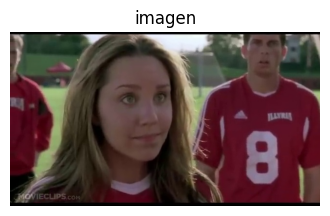

Caption 1: a girl in a soccer uniform confronts a guy on a soccer field



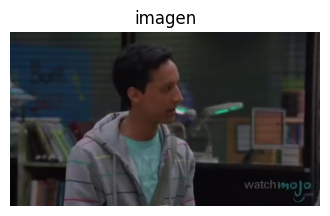

Caption 1: a classroom scene from a movie that shows a guy freaking out and running away



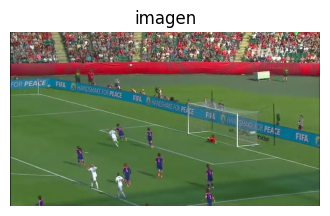

Caption 1: a game of soccer is being played



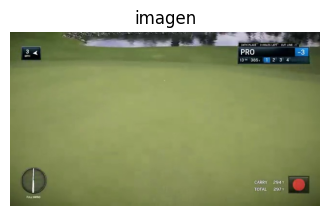

Caption 1: a golfer is walking away from the hole after he makes a put



In [13]:
import matplotlib.pyplot as plt


def show_examples(manifest: pd.DataFrame, n: int = 6) -> None:
    sample = manifest.sample(min(n, len(manifest)), random_state=SEED)
    for _, row in sample.iterrows():
        image = Image.open(row["image_path"]).convert("RGB")
        plt.figure(figsize=(4, 4))
        plt.imshow(image)
        plt.axis("off")
        plt.title(str(row.get("image_id", "imagen")))
        plt.show()
        print("Caption 1:", row.get("caption_1", "sin_caption"))
        print()

show_examples(manifest, n=4)

### **Evaluación con CLIP**

#### **Embeddings imagen texto y recuperación**

CLIP usa un encoder de imagen y un encoder de texto para proyectar ambas modalidades a un espacio latente común. En esta tarea se evalúa si el texto correcto queda cerca de su imagen.

In [15]:
from transformers import CLIPModel, CLIPProcessor

clip_model = CLIPModel.from_pretrained(CONFIG.clip_model_name).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(CONFIG.clip_model_name)
clip_model.eval()

caption_columns = get_caption_columns(manifest)
eval_manifest = manifest.head(CONFIG.evaluation_samples).copy().reset_index(drop=True)
primary_captions = eval_manifest[caption_columns[0]].astype(str).tolist()
image_paths = eval_manifest["image_path"].astype(str).tolist()

print(f"Casos evaluados: {len(eval_manifest)}")

/usr/local/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Casos evaluados: 116


In [16]:
@torch.no_grad()
def encode_images(image_paths: Sequence[str], batch_size: int) -> torch.Tensor:
    features = []
    for start in tqdm(range(0, len(image_paths), batch_size), desc="Codificando imágenes"):
        batch_paths = image_paths[start:start + batch_size]
        images = [Image.open(path).convert("RGB") for path in batch_paths]
        inputs = clip_processor(images=images, return_tensors="pt", padding=True).to(DEVICE)
        output = clip_model.get_image_features(**inputs)
        output = torch.nn.functional.normalize(output, dim=-1)
        features.append(output.cpu())
    return torch.cat(features, dim=0)


@torch.no_grad()
def encode_texts(texts: Sequence[str], batch_size: int) -> torch.Tensor:
    features = []
    for start in tqdm(range(0, len(texts), batch_size), desc="Codificando textos"):
        batch_texts = list(texts[start:start + batch_size])
        inputs = clip_processor(text=batch_texts, return_tensors="pt", padding=True, truncation=True).to(DEVICE)
        output = clip_model.get_text_features(**inputs)
        output = torch.nn.functional.normalize(output, dim=-1)
        features.append(output.cpu())
    return torch.cat(features, dim=0)


image_embeddings = encode_images(image_paths, CONFIG.batch_size)
text_embeddings = encode_texts(primary_captions, CONFIG.batch_size)
similarity_matrix = image_embeddings @ text_embeddings.T
print(similarity_matrix.shape)

Codificando imágenes:   0%|          | 0/8 [00:00<?, ?it/s]

Codificando textos:   0%|          | 0/8 [00:00<?, ?it/s]

torch.Size([116, 116])


In [18]:
def recall_at_k(similarity: torch.Tensor, k_values: Sequence[int]) -> Dict[str, float]:
    n = similarity.shape[0]
    results = {}
    targets = torch.arange(n)
    for k in k_values:
        top_image_to_text = similarity.topk(k, dim=1).indices
        ok_i2t = (top_image_to_text == targets.unsqueeze(1)).any(dim=1).float().mean().item()

        top_text_to_image = similarity.T.topk(k, dim=1).indices
        ok_t2i = (top_text_to_image == targets.unsqueeze(1)).any(dim=1).float().mean().item()

        results[f"imagen_a_texto_R@{k}"] = ok_i2t
        results[f"texto_a_imagen_R@{k}"] = ok_t2i
    return results


clip_retrieval_metrics = recall_at_k(similarity_matrix, [1, 5, 10])
clip_retrieval_metrics

{'imagen_a_texto_R@1': 0.2068965584039688,
 'texto_a_imagen_R@1': 0.18103447556495667,
 'imagen_a_texto_R@5': 0.43103447556495667,
 'texto_a_imagen_R@5': 0.43103447556495667,
 'imagen_a_texto_R@10': 0.5603448152542114,
 'texto_a_imagen_R@10': 0.5862069129943848}

### **Baseline inicial**

#### **Captions desplazados**

Un resultado serio debe compararse contra un baseline. Aquí se desplazan los captions para romper la correspondencia imagen texto. Si el sistema real no supera claramente este baseline, la evaluación no sostiene la hipótesis de alineamiento.

In [19]:
def shifted_texts(texts: Sequence[str], shift: int = 1) -> List[str]:
    values = list(texts)
    if not values:
        return []
    shift = shift % len(values)
    return values[shift:] + values[:shift]


baseline_captions = shifted_texts(primary_captions, shift=max(1, len(primary_captions) // 3))
baseline_text_embeddings = encode_texts(baseline_captions, CONFIG.batch_size)
baseline_similarity = image_embeddings @ baseline_text_embeddings.T
baseline_metrics = recall_at_k(baseline_similarity, [1, 5, 10])

comparison_metrics = pd.DataFrame([
    {"sistema": "CLIP_con_pares_reales", **clip_retrieval_metrics},
    {"sistema": "baseline_captions_desplazados", **baseline_metrics},
])
comparison_path = OUTPUT_TABLES / "comparacion_retrieval.csv"
comparison_metrics.to_csv(comparison_path, index=False)
comparison_metrics

Codificando textos:   0%|          | 0/8 [00:00<?, ?it/s]

,sistema,imagen_a_texto_R@1,texto_a_imagen_R@1,imagen_a_texto_R@5,texto_a_imagen_R@5,imagen_a_texto_R@10,texto_a_imagen_R@10
0,CLIP_con_pares_reales,0.206897,0.181034,0.431034,0.431034,0.560345,0.586207
1,baseline_captions_desplazados,0.008621,0.017241,0.043103,0.043103,0.077586,0.094828


### **CLIPScore simplificado**

#### **Fidelidad global imagen texto**

El CLIPScore simplificado usa la similitud coseno entre embedding de imagen y embedding de texto. No reemplaza evaluación humana, pero ayuda a ordenar casos para inspección manual.

In [22]:
def compute_clipscore(similarity: torch.Tensor) -> pd.DataFrame:
    diagonal = similarity.diag().numpy()
    scores = pd.DataFrame({
        "image_id": eval_manifest["video_id"].tolist(),
        "image_path": eval_manifest["image_path"].tolist(),
        "caption": eval_manifest["caption_1"].tolist(),
        "clipscore_simplificado": diagonal,
    })
    return scores.sort_values("clipscore_simplificado", ascending=True).reset_index(drop=True)


clipscore_table = compute_clipscore(similarity_matrix)
clipscore_path = OUTPUT_TABLES / "clipscore_casos.csv"
clipscore_table.to_csv(clipscore_path, index=False)
clipscore_table.head(10)

,image_id,image_path,caption,clipscore_simplificado
0,video4177,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,a basketball game is occurring,0.187227
1,video4087,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,a basketball player celebrates winning an award,0.187810
2,video3525,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,a dog is running on a field,0.192824
3,video2967,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,a basketball player dunks the ball,0.194631
4,video3373,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,a football players are running,0.194663
5,video3872,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,two men compete in a game of table tennis by v...,0.203515
6,video1954,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,a blocky video game character is running towar...,0.204099
7,video2553,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,there is a animated character playing tennis ...,0.207123
8,video3242,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,a montoge of soccer games,0.214054
9,video3541,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,three basketball players in orange shirts perf...,0.216630


### **Métricas léxicas para captions**

#### **BLEU simple, ROUGE L y cobertura**

Estas métricas son parciales. Sirven para comparar texto generado contra referencias, pero pueden ignorar errores visuales. El estudiante debe discutir esta limitación.

In [23]:
def ngrams(tokens: Sequence[str], n: int) -> List[Tuple[str, ...]]:
    return [tuple(tokens[index:index + n]) for index in range(len(tokens) - n + 1)]


def simple_bleu(candidate: str, references: Sequence[str], n: int = 4) -> float:
    candidate_tokens = tokenize_text(candidate)
    if not candidate_tokens:
        return 0.0
    scores = []
    for size in range(1, n + 1):
        candidate_ngrams = ngrams(candidate_tokens, size)
        if not candidate_ngrams:
            scores.append(0.0)
            continue
        reference_set = set()
        for reference in references:
            reference_set.update(ngrams(tokenize_text(reference), size))
        matches = sum(1 for gram in candidate_ngrams if gram in reference_set)
        scores.append(matches / max(1, len(candidate_ngrams)))
    return float(np.mean(scores))


def longest_common_subsequence(a: Sequence[str], b: Sequence[str]) -> int:
    table = np.zeros((len(a) + 1, len(b) + 1), dtype=int)
    for i in range(1, len(a) + 1):
        for j in range(1, len(b) + 1):
            if a[i - 1] == b[j - 1]:
                table[i, j] = table[i - 1, j - 1] + 1
            else:
                table[i, j] = max(table[i - 1, j], table[i, j - 1])
    return int(table[len(a), len(b)])


def rouge_l(candidate: str, references: Sequence[str]) -> float:
    candidate_tokens = tokenize_text(candidate)
    if not candidate_tokens:
        return 0.0
    best_score = 0.0
    for reference in references:
        reference_tokens = tokenize_text(reference)
        if not reference_tokens:
            continue
        lcs = longest_common_subsequence(candidate_tokens, reference_tokens)
        precision = lcs / max(1, len(candidate_tokens))
        recall = lcs / max(1, len(reference_tokens))
        if precision + recall == 0:
            score = 0.0
        else:
            score = 2 * precision * recall / (precision + recall)
        best_score = max(best_score, score)
    return float(best_score)


def lexical_coverage(candidate: str, references: Sequence[str]) -> float:
    candidate_set = set(tokenize_text(candidate))
    reference_set = set()
    for reference in references:
        reference_set.update(tokenize_text(reference))
    if not reference_set:
        return 0.0
    return len(candidate_set.intersection(reference_set)) / len(reference_set)

### **Generación opcional con BLIP**

#### **Captioner real**

Esta sección es obligatoria si el estudiante tiene GPU o CPU suficiente. Si no se ejecuta, debe justificarse y reemplazarse por captions generados previamente, guardados en `data/processed/captions_generados.csv`.

In [24]:
def generate_blip_captions(image_paths: Sequence[str], batch_size: int) -> List[str]:
    from transformers import BlipForConditionalGeneration, BlipProcessor

    processor = BlipProcessor.from_pretrained(CONFIG.blip_model_name)
    model = BlipForConditionalGeneration.from_pretrained(CONFIG.blip_model_name).to(DEVICE)
    model.eval()
    captions = []
    for start in tqdm(range(0, len(image_paths), batch_size), desc="Generando captions con BLIP"):
        batch_paths = image_paths[start:start + batch_size]
        images = [Image.open(path).convert("RGB") for path in batch_paths]
        inputs = processor(images=images, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            generated = model.generate(**inputs, max_new_tokens=32)
        decoded = processor.batch_decode(generated, skip_special_tokens=True)
        captions.extend([text.strip() for text in decoded])
    return captions


caption_output_path = DATA_PROCESSED / "captions_generados.csv"

if CONFIG.use_blip_captioner:
    caption_subset = eval_manifest.head(CONFIG.caption_samples).copy()
    generated_captions = generate_blip_captions(caption_subset["image_path"].tolist(), CONFIG.batch_size)
    caption_subset["caption_generado"] = generated_captions
    caption_subset.to_csv(caption_output_path, index=False)
    print(f"Captions generados guardados en: {caption_output_path}")
elif caption_output_path.exists():
    caption_subset = pd.read_csv(caption_output_path)
    print("Se cargaron captions generados previamente.")
else:
    caption_subset = eval_manifest.head(CONFIG.caption_samples).copy()
    caption_subset["caption_generado"] = caption_subset["caption_1"].astype(str)
    print("Advertencia: se usan captions de referencia como marcador temporal. Para la entrega final se debe generar o cargar caption_generado real.")

caption_subset.head()

/usr/local/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Generando captions con BLIP:   0%|          | 0/8 [00:00<?, ?it/s]

Captions generados guardados en: /workspace/Exposicion2/notebook_MSR_VTT/data/processed/captions_generados.csv


,video_id,image_path,video_path,caption_1,caption_generado
0,video1002,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,/workspace/Exposicion2/notebook_MSR_VTT/data/m...,a baseball pitcher practicing his pitches,a baseball player pitching a ball on a field
1,video1030,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,/workspace/Exposicion2/notebook_MSR_VTT/data/m...,a man talks about football scores,two men in suits sitting on a tv set
2,video1071,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,/workspace/Exposicion2/notebook_MSR_VTT/data/m...,a couple of people shooting a basketball,a group of men playing basketball on a court
3,video1077,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,/workspace/Exposicion2/notebook_MSR_VTT/data/m...,a commercial for a soccer video game,a soccer game is shown in the screen
4,video1211,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,/workspace/Exposicion2/notebook_MSR_VTT/data/m...,a cowboy and a police officer firings guns fol...,a soccer field with a goal and a goal post


In [25]:
def evaluate_generated_captions(table: pd.DataFrame) -> pd.DataFrame:
    caption_columns = get_caption_columns(table)
    rows = []
    for _, row in table.iterrows():
        references = [str(row[column]) for column in caption_columns if pd.notna(row[column])]
        candidate = str(row["caption_generado"])
        rows.append({
            "image_id": row.get("image_id", "sin_id"),
            "caption_generado": candidate,
            "bleu_simple": simple_bleu(candidate, references),
            "rouge_l": rouge_l(candidate, references),
            "cobertura_lexica": lexical_coverage(candidate, references),
        })
    return pd.DataFrame(rows)


caption_metrics = evaluate_generated_captions(caption_subset)
caption_metrics_path = OUTPUT_TABLES / "metricas_captions.csv"
caption_metrics.to_csv(caption_metrics_path, index=False)
caption_metrics.describe()

,bleu_simple,rouge_l,cobertura_lexica
count,116.000000,116.000000,116.000000
mean,0.119557,0.264913,0.296373
std,0.089350,0.146247,0.180775
min,0.000000,0.000000,0.000000
25%,0.070617,0.181818,0.178030
50%,0.100595,0.250000,0.250000
75%,0.142361,0.315789,0.400000
max,0.555357,0.769231,0.857143


In [26]:
print(caption_output_path)
print(caption_output_path.exists())

/workspace/Exposicion2/notebook_MSR_VTT/data/processed/captions_generados.csv
True


In [27]:
print(get_caption_columns(caption_subset))

['caption_1']


In [28]:
caption_subset[["caption_1", "caption_generado"]].sample(10, random_state=22514)

,caption_1,caption_generado
27,a girl in a soccer uniform confronts a guy on ...,a woman in a red jersey is standing in front o...
60,a classroom scene from a movie that shows a gu...,watch and share the first episode of the big b...
5,a game of soccer is being played,a soccer game is being played in a stadium
53,a golfer is walking away from the hole after h...,a golf player is playing a game on the tv screen
17,two extremely talented athletes are vying for ...,a man in red shirt standing on a court
105,a basketball player makes a slam dunk,nba live game trailer
9,a clip of a soccer match,a soccer game with a player in the middle of t...
1,a man talks about football scores,two men in suits sitting on a tv set
57,a baseball player hits the ball,a baseball player is throwing the ball
104,a basic animated clip of hockey and table tenn...,a cartoon of two men playing hockey


### **Simulación CapFilt**

#### **Captioner y filter**

BLIP usa bootstrapping para trabajar con textos web ruidosos. Aquí se simula esa idea con tres candidatos por imagen: un caption de referencia, un caption generado y un caption desplazado que actúa como ruido.

In [31]:
def build_capfilt_candidates(table: pd.DataFrame) -> pd.DataFrame:
    shifted = shifted_texts(table["caption_1"].astype(str).tolist(), shift=max(1, len(table) // 4))
    records = []
    for index, row in table.reset_index(drop=True).iterrows():
        records.append({
            "image_id": row["video_id"],
            "image_path": row["image_path"],
            "candidate_type": "humano_referencia",
            "candidate_caption": str(row["caption_1"]),
            "expected_label": 1,
        })
        records.append({
            "image_id": row["video_id"],
            "image_path": row["image_path"],
            "candidate_type": "captioner_sintetico",
            "candidate_caption": str(row.get("caption_generado", row["caption_1"])),
            "expected_label": 1,
        })
        records.append({
            "image_id": row["video_id"],
            "image_path": row["image_path"],
            "candidate_type": "texto_web_ruidoso",
            "candidate_caption": shifted[index],
            "expected_label": 0,
        })
    return pd.DataFrame(records)


capfilt_candidates = build_capfilt_candidates(caption_subset)
capfilt_text_embeddings = encode_texts(capfilt_candidates["candidate_caption"].tolist(), CONFIG.batch_size)
capfilt_image_embeddings = encode_images(capfilt_candidates["image_path"].tolist(), CONFIG.batch_size)
capfilt_candidates["clipscore_simplificado"] = (capfilt_image_embeddings * capfilt_text_embeddings).sum(dim=1).numpy()
capfilt_candidates.head()

Codificando textos:   0%|          | 0/22 [00:00<?, ?it/s]

Codificando imágenes:   0%|          | 0/22 [00:00<?, ?it/s]

,image_id,image_path,candidate_type,candidate_caption,expected_label,clipscore_simplificado
0,video1002,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,humano_referencia,a baseball pitcher practicing his pitches,1,0.313523
1,video1002,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,captioner_sintetico,a baseball player pitching a ball on a field,1,0.300892
2,video1002,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,texto_web_ruidoso,a baseball player hits a ball and it is out at...,0,0.303546
3,video1030,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,humano_referencia,a man talks about football scores,1,0.258343
4,video1030,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,captioner_sintetico,two men in suits sitting on a tv set,1,0.272357


In [32]:
#ADICION
capfilt_candidates["candidate_type"].value_counts()

candidate_type
humano_referencia      116
captioner_sintetico    116
texto_web_ruidoso      116
Name: count, dtype: int64

In [33]:
def evaluate_filter_threshold(candidates: pd.DataFrame, threshold: float) -> Dict[str, float]:
    predicted = (candidates["clipscore_simplificado"] >= threshold).astype(int)
    expected = candidates["expected_label"].astype(int)
    tp = int(((predicted == 1) & (expected == 1)).sum())
    fp = int(((predicted == 1) & (expected == 0)).sum())
    fn = int(((predicted == 0) & (expected == 1)).sum())
    tn = int(((predicted == 0) & (expected == 0)).sum())
    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)
    accuracy = (tp + tn) / max(1, tp + tn + fp + fn)
    return {
        "umbral": threshold,
        "precision": precision,
        "recall": recall,
        "accuracy": accuracy,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    }


thresholds = np.linspace(
    float(capfilt_candidates["clipscore_simplificado"].min()),
    float(capfilt_candidates["clipscore_simplificado"].max()),
    num=21,
)
filter_results = pd.DataFrame([evaluate_filter_threshold(capfilt_candidates, float(value)) for value in thresholds])
filter_results_path = OUTPUT_TABLES / "capfilt_umbral.csv"
filter_results.to_csv(filter_results_path, index=False)
filter_results.sort_values("accuracy", ascending=False).head()

,umbral,precision,recall,accuracy,tp,fp,fn,tn
12,0.238678,0.912442,0.853448,0.847701,198,19,34,97
11,0.222224,0.839695,0.948276,0.844828,220,42,12,74
10,0.205770,0.786713,0.969828,0.804598,225,61,7,55
13,0.255132,0.927778,0.719828,0.775862,167,13,65,103
9,0.189316,0.727848,0.991379,0.747126,230,86,2,30


### NOTA SOBRE EL UMBRAL 0.238678

Precisión = 0.912 (91.2%): de todos los captions que el sistema aceptó como correctos, el 91.2% correspondían realmente a captions positivos (humanos o generados por BLIP).

Recall = 0.853 (85.3%): el sistema recuperó el 85.3% de los captions positivos, aunque algunos fueron rechazados.

Accuracy = 0.848 (84.8%): clasificó correctamente el 84.8% de todos los candidatos evaluados.

La matriz de confusión también es consistente:

- **TP = 198:** captions positivos aceptados correctamente.
- **FP = 19:** textos ruidosos aceptados por error.
- **FN = 34:** captions positivos rechazados.
- **TN = 97:** textos ruidosos rechazados correctamente.

Este umbral ofrece un equilibrio entre precisión y recall, manteniendo una baja cantidad de falsos positivos sin sacrificar excesivamente la recuperación de captions válidos.

### **Ablación visual**

#### **Robustez ante degradación**

Esta sección mide si el alineamiento imagen texto cambia cuando la imagen pierde información. El estudiante debe comparar imagen original, baja resolución, desenfoque, escala de grises y recorte central.

In [36]:
def degrade_image(image: Image.Image, mode: str) -> Image.Image:
    image = image.convert("RGB")
    if mode == "original":
        return image
    if mode == "baja_resolucion":
        small = image.resize((max(1, image.width // 4), max(1, image.height // 4)))
        return small.resize(image.size)
    if mode == "desenfoque":
        return image.filter(ImageFilter.GaussianBlur(radius=3))
    if mode == "grises":
        return ImageOps.grayscale(image).convert("RGB")
    if mode == "recorte_central":
        width, height = image.size
        margin_w = width // 5
        margin_h = height // 5
        cropped = image.crop((margin_w, margin_h, width - margin_w, height - margin_h))
        return cropped.resize(image.size)
    raise ValueError(f"Modo de degradación no reconocido: {mode}")


def build_degraded_dataset(manifest: pd.DataFrame, modes: Sequence[str]) -> pd.DataFrame:
    records = []
    degraded_dir = DATA_PROCESSED / "degradadas"
    degraded_dir.mkdir(parents=True, exist_ok=True)
    for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc="Creando imágenes degradadas"):
        image = Image.open(row["image_path"]).convert("RGB")
        for mode in modes:
            output_path = degraded_dir / f"{row['video_id']}_{mode}.jpg"
            degrade_image(image, mode).save(output_path)
            records.append({
                "image_id": row["video_id"],
                "mode": mode,
                "image_path": str(output_path),
                "caption_1": row["caption_1"],
            })
    return pd.DataFrame(records)


ablacion_modes = ["original", "baja_resolucion", "desenfoque", "grises", "recorte_central"]
ablacion_manifest = build_degraded_dataset(eval_manifest.head(80), ablacion_modes)
ablacion_manifest.head()

Creando imágenes degradadas:   0%|          | 0/80 [00:00<?, ?it/s]

,image_id,mode,image_path,caption_1
0,video1002,original,/workspace/Exposicion2/notebook_MSR_VTT/data/p...,a baseball pitcher practicing his pitches
1,video1002,baja_resolucion,/workspace/Exposicion2/notebook_MSR_VTT/data/p...,a baseball pitcher practicing his pitches
2,video1002,desenfoque,/workspace/Exposicion2/notebook_MSR_VTT/data/p...,a baseball pitcher practicing his pitches
3,video1002,grises,/workspace/Exposicion2/notebook_MSR_VTT/data/p...,a baseball pitcher practicing his pitches
4,video1002,recorte_central,/workspace/Exposicion2/notebook_MSR_VTT/data/p...,a baseball pitcher practicing his pitches


In [37]:
def evaluate_visual_degradation(ablacion_manifest: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for mode, group in ablacion_manifest.groupby("mode"):
        image_features = encode_images(group["image_path"].tolist(), CONFIG.batch_size)
        text_features = encode_texts(group["caption_1"].astype(str).tolist(), CONFIG.batch_size)
        similarity = image_features @ text_features.T
        metrics = recall_at_k(similarity, [1, 5, 10])
        metrics["modo"] = mode
        metrics["clipscore_promedio"] = float(similarity.diag().mean().item())
        rows.append(metrics)
    return pd.DataFrame(rows).sort_values("modo")


ablacion_results = evaluate_visual_degradation(ablacion_manifest)
ablacion_results_path = OUTPUT_TABLES / "ablacion_visual.csv"
ablacion_results.to_csv(ablacion_results_path, index=False)
ablacion_results

Codificando imágenes:   0%|          | 0/5 [00:00<?, ?it/s]

Codificando textos:   0%|          | 0/5 [00:00<?, ?it/s]

Codificando imágenes:   0%|          | 0/5 [00:00<?, ?it/s]

Codificando textos:   0%|          | 0/5 [00:00<?, ?it/s]

Codificando imágenes:   0%|          | 0/5 [00:00<?, ?it/s]

...

Codificando imágenes:   0%|          | 0/5 [00:00<?, ?it/s]

Codificando textos:   0%|          | 0/5 [00:00<?, ?it/s]

Codificando imágenes:   0%|          | 0/5 [00:00<?, ?it/s]

Codificando textos:   0%|          | 0/5 [00:00<?, ?it/s]

,imagen_a_texto_R@1,texto_a_imagen_R@1,imagen_a_texto_R@5,texto_a_imagen_R@5,imagen_a_texto_R@10,texto_a_imagen_R@10,modo,clipscore_promedio
0,0.3125,0.2625,0.5875,0.6375,0.7625,0.7500,baja_resolucion,0.274255
1,0.2625,0.2500,0.5000,0.5750,0.7625,0.7625,desenfoque,0.269599
2,0.2500,0.2500,0.5875,0.5250,0.7250,0.7250,grises,0.261734
3,0.2750,0.2250,0.5375,0.6000,0.7250,0.7125,original,0.269037
4,0.2375,0.2250,0.5500,0.4875,0.6875,0.6375,recorte_central,0.270488


Notas
Como los embeddings están normalizados, este producto matricial equivale al coseno de similitud entre todas las imágenes y todos los textos.
Para medir el CLIPScore promedio de tu conjunto de evaluación, solo interesan los pares correctos, que son precisamente los de la diagonal.

### **Análisis de errores**

#### **Taxonomía obligatoria**

El análisis debe clasificar errores con estas categorías:

```text
objeto, acción, conteo, relación espacial, OCR, atributo, alucinación, sesgo, respuesta vaga, otro
```

Cada estudiante debe anotar manualmente al menos 30 casos. Se deben incluir fallos y aciertos, no solo ejemplos favorables.

In [38]:
ERROR_CATEGORIES = [
    "objeto",
    "acción",
    "conteo",
    "relación espacial",
    "OCR",
    "atributo",
    "alucinación",
    "sesgo",
    "respuesta vaga",
    "otro",
]


def prepare_error_sheet(scores: pd.DataFrame, n_cases: int) -> pd.DataFrame:
    worst = scores.head(n_cases // 2).copy()
    random_cases = scores.sample(n=min(n_cases - len(worst), len(scores)), random_state=SEED).copy()
    selected = pd.concat([worst, random_cases], ignore_index=True).drop_duplicates("image_id")
    selected["categoria_error"] = "pendiente"
    selected["severidad_1_a_5"] = "pendiente"
    selected["evidencia_visual"] = "pendiente"
    selected["comentario_tecnico"] = "pendiente"
    return selected


error_sheet = prepare_error_sheet(clipscore_table, CONFIG.error_cases)
error_sheet_path = OUTPUT_TABLES / "plantilla_analisis_errores.csv"
error_sheet.to_csv(error_sheet_path, index=False)
print(f"Plantilla de análisis de errores guardada en: {error_sheet_path}")
error_sheet.head()

Plantilla de análisis de errores guardada en: /workspace/Exposicion2/notebook_MSR_VTT/outputs/tables/plantilla_analisis_errores.csv


,image_id,image_path,caption,clipscore_simplificado,categoria_error,severidad_1_a_5,evidencia_visual,comentario_tecnico
0,video4177,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,a basketball game is occurring,0.187227,pendiente,pendiente,pendiente,pendiente
1,video4087,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,a basketball player celebrates winning an award,0.187810,pendiente,pendiente,pendiente,pendiente
2,video3525,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,a dog is running on a field,0.192824,pendiente,pendiente,pendiente,pendiente
3,video2967,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,a basketball player dunks the ball,0.194631,pendiente,pendiente,pendiente,pendiente
4,video3373,/workspace/Exposicion2/notebook_MSR_VTT/data/r...,a football players are running,0.194663,pendiente,pendiente,pendiente,pendiente


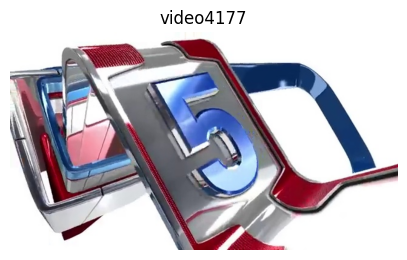

Caption evaluado: a basketball game is occurring
CLIPScore simplificado: 0.1872271
Categorías permitidas: objeto, acción, conteo, relación espacial, OCR, atributo, alucinación, sesgo, respuesta vaga, otro


In [39]:
def show_error_case(error_table: pd.DataFrame, index: int) -> None:
    row = error_table.iloc[index]
    image = Image.open(row["image_path"]).convert("RGB")
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(str(row["image_id"]))
    plt.show()
    print("Caption evaluado:", row["caption"])
    print("CLIPScore simplificado:", row["clipscore_simplificado"])
    print("Categorías permitidas:", ", ".join(ERROR_CATEGORIES))

show_error_case(error_sheet, 0)

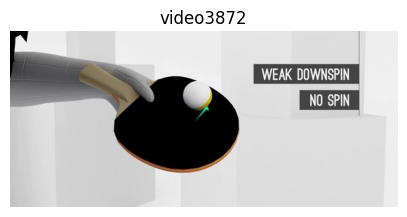

Caption evaluado: two men compete in a game of table tennis by vigorously volleying the ping pong ball over the net
CLIPScore simplificado: 0.2035145
Categorías permitidas: objeto, acción, conteo, relación espacial, OCR, atributo, alucinación, sesgo, respuesta vaga, otro


In [40]:
show_error_case(error_sheet, 5)

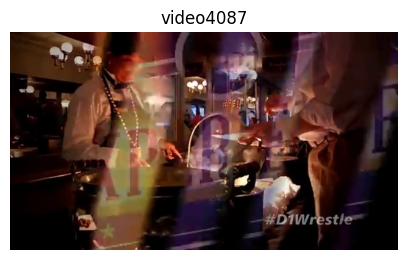

Caption evaluado: a basketball player celebrates winning an award
CLIPScore simplificado: 0.18780987
Categorías permitidas: objeto, acción, conteo, relación espacial, OCR, atributo, alucinación, sesgo, respuesta vaga, otro


In [46]:
show_error_case(error_sheet, 1)

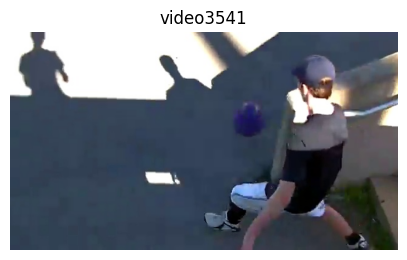

Caption evaluado: three basketball players in orange shirts perform fantastic moves
CLIPScore simplificado: 0.2166304
Categorías permitidas: objeto, acción, conteo, relación espacial, OCR, atributo, alucinación, sesgo, respuesta vaga, otro


In [54]:
show_error_case(error_sheet, 9)

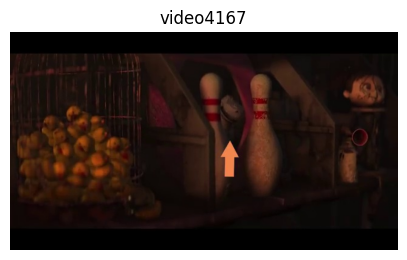

Caption evaluado: a group of mermaids are a swimming in the ocean with other water creatures
CLIPScore simplificado: 0.2224009
Categorías permitidas: objeto, acción, conteo, relación espacial, OCR, atributo, alucinación, sesgo, respuesta vaga, otro


In [55]:
show_error_case(error_sheet, 10)

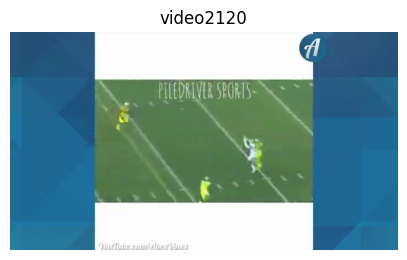

Caption evaluado: a golfer drives a ball
CLIPScore simplificado: 0.22396293
Categorías permitidas: objeto, acción, conteo, relación espacial, OCR, atributo, alucinación, sesgo, respuesta vaga, otro


In [56]:
show_error_case(error_sheet, 11)

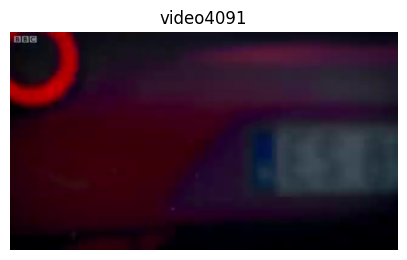

Caption evaluado: a star on the abc network enjoys jet-skiing on a lake
CLIPScore simplificado: 0.22856197
Categorías permitidas: objeto, acción, conteo, relación espacial, OCR, atributo, alucinación, sesgo, respuesta vaga, otro


In [61]:
show_error_case(error_sheet, 16)

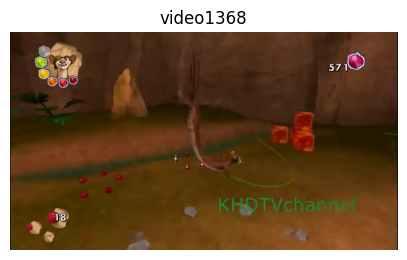

Caption evaluado: a cartoon animal is running around
CLIPScore simplificado: 0.26002792
Categorías permitidas: objeto, acción, conteo, relación espacial, OCR, atributo, alucinación, sesgo, respuesta vaga, otro


In [68]:
show_error_case(error_sheet, 22)

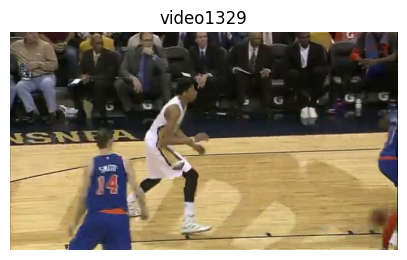

Caption evaluado: a basketball assist leads to a slam-dunk
CLIPScore simplificado: 0.29292002
Categorías permitidas: objeto, acción, conteo, relación espacial, OCR, atributo, alucinación, sesgo, respuesta vaga, otro


In [78]:
show_error_case(error_sheet, 32)

### **Perturbación textual**

#### **Sensibilidad a negación, conteo y atributos**

El objetivo es detectar si el modelo distingue captions correctos de captions alterados. Se modifican atributos, conteos, objetos o negaciones de forma controlada.

In [42]:
def build_text_perturbations(caption: str) -> List[Tuple[str, str]]:
    tokens = tokenize_text(caption)
    original = " ".join(tokens)
    perturbations = [("original", original)]
    perturbations.append(("negacion", f"no {original}"))
    perturbations.append(("conteo", f"dos {original}"))
    perturbations.append(("atributo", f"{original} de color rojo"))
    perturbations.append(("objeto_externo", f"{original} con un avion visible"))
    return perturbations


def evaluate_text_perturbations(manifest: pd.DataFrame, n: int = 40) -> pd.DataFrame:
    records = []
    subset = manifest.head(n).copy()
    for _, row in subset.iterrows():
        for perturbation_type, text in build_text_perturbations(str(row["caption_1"])):
            records.append({
                "image_id": row["video_id"],
                "image_path": row["image_path"],
                "tipo_perturbacion": perturbation_type,
                "texto": text,
            })
    table = pd.DataFrame(records)
    image_features = encode_images(table["image_path"].tolist(), CONFIG.batch_size)
    text_features = encode_texts(table["texto"].tolist(), CONFIG.batch_size)
    table["clipscore_simplificado"] = (image_features * text_features).sum(dim=1).numpy()
    return table


perturbation_results = evaluate_text_perturbations(eval_manifest, n=40)
perturbation_path = OUTPUT_TABLES / "perturbacion_textual.csv"
perturbation_results.to_csv(perturbation_path, index=False)
perturbation_results.groupby("tipo_perturbacion")["clipscore_simplificado"].describe()

Codificando imágenes:   0%|          | 0/13 [00:00<?, ?it/s]

Codificando textos:   0%|          | 0/13 [00:00<?, ?it/s]

,count,mean,std,min,25%,50%,75%,max
tipo_perturbacion,,,,,,,,
atributo,40.0,0.265435,0.039573,0.165840,0.248093,0.266101,0.281011,0.358357
conteo,40.0,0.268390,0.035821,0.199798,0.244474,0.270248,0.287021,0.357111
negacion,40.0,0.264384,0.032977,0.203891,0.244971,0.254881,0.286629,0.349712
objeto_externo,40.0,0.272101,0.034836,0.200709,0.246495,0.266592,0.299094,0.356336
original,40.0,0.276785,0.035812,0.204099,0.252808,0.271657,0.295108,0.362634


### **Figuras para la exposición**

#### **Matriz de similitud y comparación de métricas**

La exposición debe incluir al menos dos figuras generadas desde el cuaderno, no imágenes copiadas de internet.

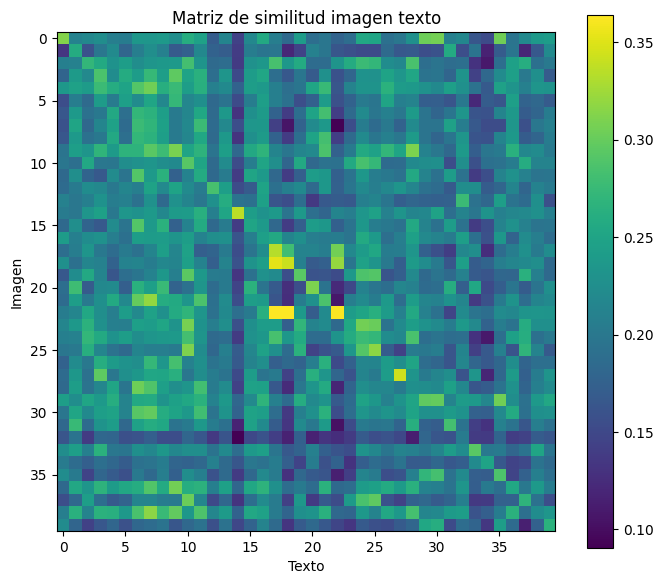

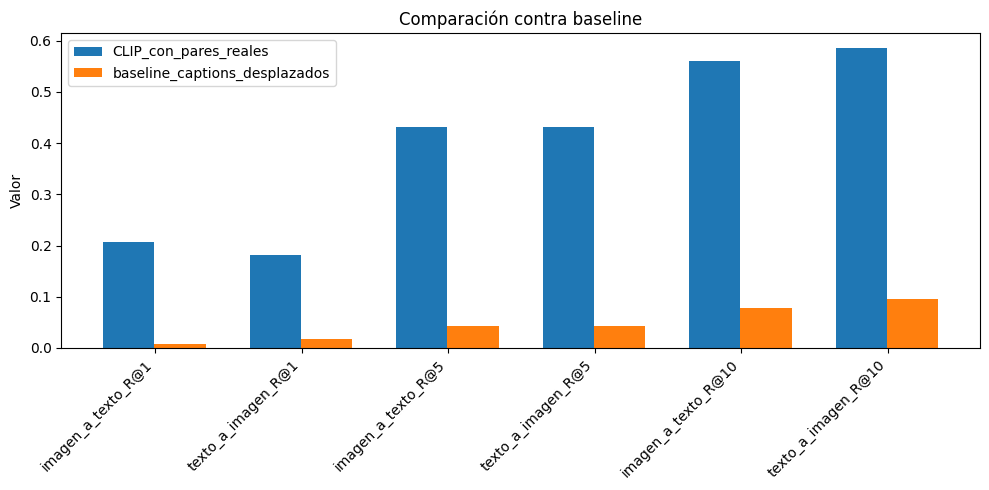

In [43]:
def plot_similarity_matrix(similarity: torch.Tensor, output_path: Path, max_items: int = 40) -> None:
    values = similarity[:max_items, :max_items].numpy()
    plt.figure(figsize=(7, 6))
    plt.imshow(values)
    plt.colorbar()
    plt.title("Matriz de similitud imagen texto")
    plt.xlabel("Texto")
    plt.ylabel("Imagen")
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()


def plot_metric_bars(table: pd.DataFrame, output_path: Path) -> None:
    metric_columns = [column for column in table.columns if column != "sistema"]
    melted = table.melt(id_vars="sistema", value_vars=metric_columns, var_name="metrica", value_name="valor")
    plt.figure(figsize=(10, 5))
    for index, system in enumerate(melted["sistema"].unique()):
        subset = melted[melted["sistema"] == system]
        positions = np.arange(len(subset)) + index * 0.35
        plt.bar(positions, subset["valor"], width=0.35, label=system)
    plt.xticks(np.arange(len(metric_columns)) + 0.18, metric_columns, rotation=45, ha="right")
    plt.ylabel("Valor")
    plt.title("Comparación contra baseline")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()


plot_similarity_matrix(similarity_matrix, OUTPUT_FIGURES / "matriz_similitud_clip.png")
plot_metric_bars(comparison_metrics, OUTPUT_FIGURES / "comparacion_baseline.png")

### **Consolidación de resultados**

#### **Archivo único de métricas**

Todo resultado usado en la exposición debe quedar guardado en disco.

In [44]:
all_metrics = {
    "retrieval_clip": clip_retrieval_metrics,
    "retrieval_baseline": baseline_metrics,
    "caption_metrics_mean": caption_metrics.select_dtypes(include=[np.number]).mean().to_dict(),
    "capfilt_best": filter_results.sort_values("accuracy", ascending=False).head(1).to_dict(orient="records")[0],
    "ablacion_visual": ablacion_results.to_dict(orient="records"),
}

metrics_path = OUTPUT_METRICS / "metricas_finales.json"
metrics_path.write_text(json.dumps(all_metrics, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Métricas finales guardadas en: {metrics_path}")

Métricas finales guardadas en: /workspace/Exposicion2/notebook_MSR_VTT/outputs/metrics/metricas_finales.json


### **Reporte técnico**

#### **Plantilla obligatoria**

El estudiante debe completar `reports/reporte_exposicion_2.md`. El reporte debe ser breve, técnico y reproducible.

In [45]:
def write_report_template(path: Path) -> None:
    text = """
### Reporte individual de evaluación multimodal

#### Datos del estudiante

Nombre:
Repositorio:
Commit final:
Fecha:

#### Tarea definida

Explica qué sistema evaluastes, qué entrada recibe y qué salida produce.

#### Dataset

Describe el dataset usado, número de imágenes, número de captions, filtros aplicados y partición evaluada.

#### Modelos evaluados

Indica modelos, checkpoints, parámetros relevantes y configuración de inferencia.

#### Baselines

Explica el baseline usado y por qué es una comparación mínima razonable.

#### Métricas

Reporte Recall@K, CLIPScore simplificado, métricas léxicas, resultados de CapFilt y resultados de ablación visual.

#### Análisis de errores

Incluye tabla de errores con categorías: objeto, acción, conteo, relación espacial, OCR, atributo, alucinación, sesgo, respuesta vaga y otro.

#### Discusión de limitaciones

Explica qué no capturan las métricas, dónde falla el modelo y qué supuestos pueden afectar la validez del experimento.

#### Conexión conceptual

Relaciona los resultados con BERT, VisualBERT, UNITER, ViLT, BLIP, BLIP-2 y LLaVA.

#### Conclusión

Resume si el sistema muestra alineamiento multimodal robusto o solo desempeño parcial.
""".strip()
    path.write_text(text, encoding="utf-8")


report_path = REPORTS / "reporte_exposicion_2.md"
if not report_path.exists():
    write_report_template(report_path)
print(f"Plantilla de reporte disponible en: {report_path}")

Plantilla de reporte disponible en: /workspace/Exposicion2/notebook_MSR_VTT/reports/reporte_exposicion_2.md


### **Cierre conceptual**

#### **Relación con los modelos estudiados**

BERT introduce la gramática de tokens, embeddings y atención bidireccional. VisualBERT, UNITER y ViLT extienden esa gramática a tokens visuales. BLIP agrega generación y limpieza de datos mediante bootstrapping. CoCa combina alineamiento contrastivo y captioning. BLIP-2 conecta visión congelada con LLMs congelados mediante Q-Former. LLaVA lleva la imagen al espacio del LLM para seguir instrucciones visuales.

Este cuaderno evalúa esa línea desde el punto de vista experimental: alineamiento, recuperación, generación, filtrado, ablación, error, reproducibilidad y límites. Esa es la base mínima para una exposición académica fuerte.